# Reconciliation (DTL) — the core algorithm

Goal: fill a table `cost[p][h]` = the cheapest cost to explain the parasite subtree under `p`, if `p` sits on host `h`. We fill it bottom-up; the answer is the best value at the parasite root.

**Chunk 1:** load the data and set up convenient access.

In [1]:
from Bio import Phylo
import json

# --- which dataset ---
DATASET = 'gopher_louse'
folder = f'data/{DATASET}'

# --- load the two trees + the mapping ---
host_tree = Phylo.read(f'{folder}/gopher.nwk', 'newick')       # hosts = gophers
parasite_tree = Phylo.read(f'{folder}/louse.nwk', 'newick')    # parasites = lice
with open(f'{folder}/mapping.json', encoding='utf-8') as f:
    mapping = json.load(f)                                     # parasite name -> host name

# --- event costs (the knobs) ---
C = {'cospeciation': 0, 'duplication': 1, 'loss': 1, 'switch': 5}
INF = float('inf')

# --- convenient access ---
host_nodes = list(host_tree.find_clades())          # every node of the host tree
parasite_nodes = list(parasite_tree.find_clades())  # every node of the parasite tree
host_leaf_by_name = {leaf.name: leaf for leaf in host_tree.get_terminals()}

print(f'Host nodes: {len(host_nodes)} (leaves: {host_tree.count_terminals()})')
print(f'Parasite nodes: {len(parasite_nodes)} (leaves: {parasite_tree.count_terminals()})')
print(f'Costs: {C}')

Host nodes: 15 (leaves: 8)
Parasite nodes: 19 (leaves: 10)
Costs: {'cospeciation': 0, 'duplication': 1, 'loss': 1, 'switch': 5}


In [2]:
# Chunk 2: base case — fill the cost table for the parasite LEAVES
# cost[(p, h)] = cheapest cost to explain the parasite-subtree under p, if p sits on host h.
# We store only finite entries; a MISSING key means "impossible" (infinity).

cost = {}  # (parasite_node, host_node) -> number

def get_cost(p, h):
    return cost.get((p, h), INF)

# A parasite leaf must sit on its own known host leaf (cost 0). Anywhere else = impossible.
for p_leaf in parasite_tree.get_terminals():
    its_host = host_leaf_by_name[mapping[p_leaf.name]]
    cost[(p_leaf, its_host)] = 0

# check what we filled
print('Base case — each parasite leaf on its host:')
for p_leaf in parasite_tree.get_terminals():
    its_host = host_leaf_by_name[mapping[p_leaf.name]]
    print(f'  {p_leaf.name:>16} on {its_host.name:<14} -> cost {get_cost(p_leaf, its_host)}')

Base case — each parasite leaf on its host:
          T. wardi on T. talpoides   -> cost 0
          T. minor on T. bottae      -> cost 0
      G. thomomyus on T. talpoides   -> cost 0
        G. actuosi on T. bottae      -> cost 0
         G. ewingi on G. bursarius   -> cost 0
        G. chapini on O. hispidus    -> cost 0
     G. panamensis on O. cavator     -> cost 0
        G. setzeri on O. underwoodi  -> cost 0
       G. cherriei on O. cherriei    -> cost 0
  G. costaricensis on O. heterodus   -> cost 0


In [4]:
# Chunk 3: the recurrence — fill the whole table and return the cheapest cost.
# We wrap everything (base case + events + losses) into ONE function.

def reconcile(host_tree, parasite_tree, phi, C):
    INF = float('inf')
    host_nodes = list(host_tree.find_clades())
    host_post = list(host_tree.find_clades(order='postorder'))
    host_leaf_by_name = {leaf.name: leaf for leaf in host_tree.get_terminals()}

    # For a host-switch: which hosts may we jump TO? Any that is neither an
    # ancestor nor a descendant of the current host ("incomparable").
    desc = {h: set(h.find_clades()) for h in host_nodes}
    incomparable = {h: [g for g in host_nodes if g not in desc[h] and h not in desc[g]]
                    for h in host_nodes}

    cost = {}         # cost[(p,h)]       = cheapest to explain p's subtree with p EXACTLY at h
    best_below = {}   # best_below[(p,h)] = cheapest with p at h OR below it (paying losses)

    def C_at(p, h):    return cost.get((p, h), INF)
    def C_below(p, h): return best_below.get((p, h), INF)

    # Walk the parasite tree bottom-up (children before parents)
    for p in parasite_tree.find_clades(order='postorder'):

        if p.is_terminal():
            # BASE CASE: a parasite leaf sits on its own known host (cost 0)
            cost[(p, host_leaf_by_name[phi[p.name]])] = 0
        else:
            a, b = p.clades  # the two child parasites
            for h in host_nodes:
                options = []
                # Cospeciation: the children go into the two different host-child subtrees
                if not h.is_terminal():
                    h1, h2 = h.clades
                    options.append(C['cospeciation'] +
                                   min(C_below(a, h1) + C_below(b, h2),
                                       C_below(a, h2) + C_below(b, h1)))
                # Duplication: both children stay within h's subtree
                options.append(C['duplication'] + C_below(a, h) + C_below(b, h))
                # Host-switch: one child stays, the other jumps to an incomparable host
                jump_a = min([C_below(a, g) for g in incomparable[h]], default=INF)
                jump_b = min([C_below(b, g) for g in incomparable[h]], default=INF)
                options.append(C['switch'] + min(C_below(a, h) + jump_b,
                                                  C_below(b, h) + jump_a))
                if min(options) < INF:
                    cost[(p, h)] = min(options)

        # Fill best_below for p (a loss lets p slide one step down the host tree)
        for h in host_post:
            if h.is_terminal():
                val = C_at(p, h)
            else:
                h1, h2 = h.clades
                val = min(C_at(p, h), C['loss'] + C_below(p, h1), C['loss'] + C_below(p, h2))
            if val < INF:
                best_below[(p, h)] = val

    # The answer: cheapest placement of the parasite ROOT on any host node
    root = parasite_tree.root
    return min(C_at(root, h) for h in host_nodes)


# Try it on gopher_louse:
answer = reconcile(host_tree, parasite_tree, mapping, C)
print(f"Minimum reconciliation cost for {DATASET}: {answer}")

Minimum reconciliation cost for gopher_louse: 12


In [5]:
# Chunk 4: the research experiment — how does the answer change with the host-switch price?
print("host-switch price  ->  minimum total cost")
for t in [0, 1, 2, 3, 5, 10]:
    Ct = {'cospeciation': 0, 'duplication': 1, 'loss': 1, 'switch': t}
    result = reconcile(host_tree, parasite_tree, mapping, Ct)
    print(f"        {t:>2}          ->        {result}")

host-switch price  ->  minimum total cost
         0          ->        0
         1          ->        4
         2          ->        7
         3          ->        10
         5          ->        12
        10          ->        14


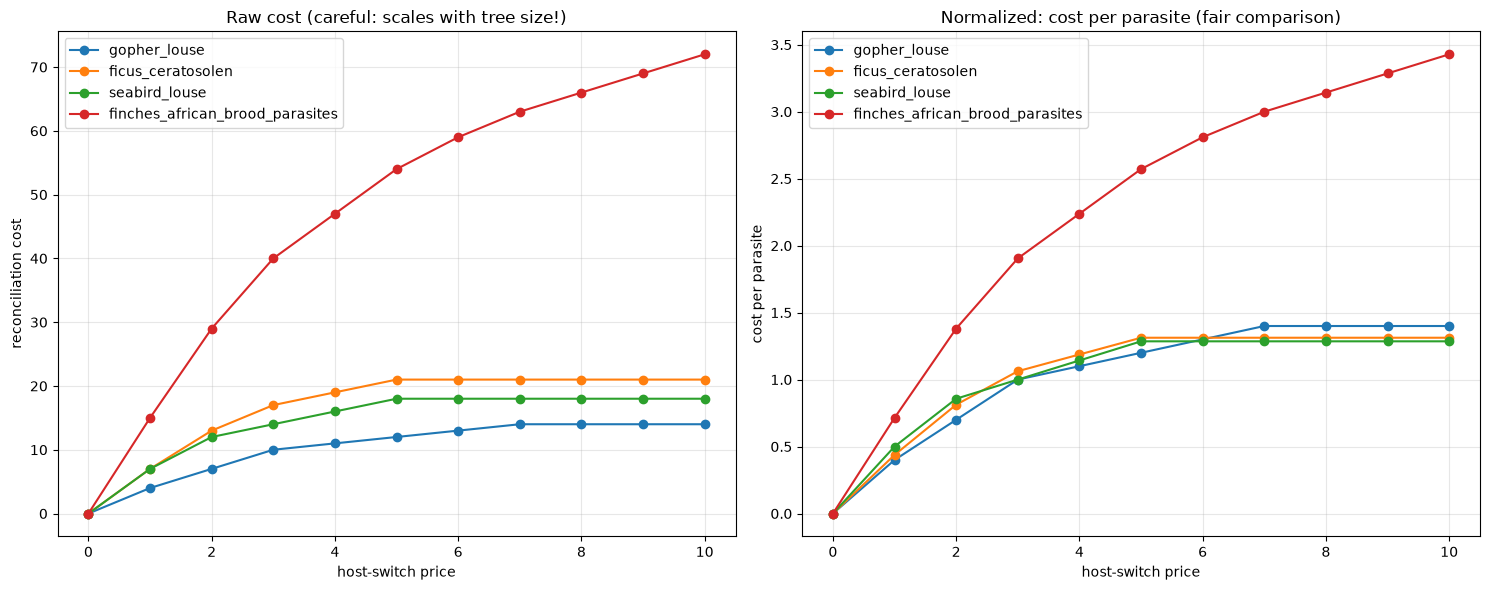

In [6]:
# Chunk 5: compare all datasets — how faithful is each host-parasite system?
import glob
import matplotlib.pyplot as plt

def load_any(dataset):
    folder = f'data/{dataset}'
    with open(f'{folder}/mapping.json', encoding='utf-8') as f:
        phi = json.load(f)
    parasite_names = set(phi.keys())
    host = para = None
    for path in glob.glob(f'{folder}/*.nwk'):
        t = Phylo.read(path, 'newick')
        leaves = {leaf.name for leaf in t.get_terminals()}
        if len(leaves & parasite_names) > len(leaves) / 2:
            para = t
        else:
            host = t
    return host, para, phi

datasets = ['gopher_louse', 'ficus_ceratosolen', 'seabird_louse', 'finches_african_brood_parasites']
prices = list(range(0, 11))

fig, (ax_raw, ax_norm) = plt.subplots(1, 2, figsize=(15, 6))
for ds in datasets:
    host, para, phi = load_any(ds)
    n = para.count_terminals()
    raw = [reconcile(host, para, phi, {'cospeciation': 0, 'duplication': 1, 'loss': 1, 'switch': t})
           for t in prices]
    ax_raw.plot(prices, raw, marker='o', label=ds)
    ax_norm.plot(prices, [c / n for c in raw], marker='o', label=ds)

ax_raw.set(title='Raw cost (careful: scales with tree size!)',
           xlabel='host-switch price', ylabel='reconciliation cost')
ax_norm.set(title='Normalized: cost per parasite (fair comparison)',
            xlabel='host-switch price', ylabel='cost per parasite')
for ax in (ax_raw, ax_norm):
    ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [7]:
# Chunk 6: traceback — recover WHICH events the optimal solution used, and count them.
# Same DP as chunk 3, but after filling the tables we walk back through the winning choices.

def reconcile_trace(host_tree, parasite_tree, phi, C):
    INF = float('inf')
    host_nodes = list(host_tree.find_clades())
    host_post = list(host_tree.find_clades(order='postorder'))
    hbn = {leaf.name: leaf for leaf in host_tree.get_terminals()}
    desc = {h: set(h.find_clades()) for h in host_nodes}
    incomp = {h: [g for g in host_nodes if g not in desc[h] and h not in desc[g]] for h in host_nodes}

    cost, best_below = {}, {}
    A  = lambda p, h: cost.get((p, h), INF)         # p exactly at h
    Bl = lambda p, h: best_below.get((p, h), INF)   # p at h or below

    # ---- fill the tables (identical to chunk 3) ----
    for p in parasite_tree.find_clades(order='postorder'):
        if p.is_terminal():
            cost[(p, hbn[phi[p.name]])] = 0
        else:
            a, b = p.clades
            for h in host_nodes:
                o = []
                if not h.is_terminal():
                    h1, h2 = h.clades
                    o.append(C['cospeciation'] + min(Bl(a, h1) + Bl(b, h2), Bl(a, h2) + Bl(b, h1)))
                o.append(C['duplication'] + Bl(a, h) + Bl(b, h))
                ja = min([Bl(a, g) for g in incomp[h]], default=INF)
                jb = min([Bl(b, g) for g in incomp[h]], default=INF)
                o.append(C['switch'] + min(Bl(a, h) + jb, Bl(b, h) + ja))
                if min(o) < INF:
                    cost[(p, h)] = min(o)
        for h in host_post:
            if h.is_terminal():
                v = A(p, h)
            else:
                h1, h2 = h.clades
                v = min(A(p, h), C['loss'] + Bl(p, h1), C['loss'] + Bl(p, h2))
            if v < INF:
                best_below[(p, h)] = v

    # ---- traceback: rebuild the winning story and count events ----
    counts = {'cospeciation': 0, 'duplication': 0, 'switch': 0, 'loss': 0}

    def trace_exact(p, h):            # p placed exactly at h
        if p.is_terminal():
            return
        a, b = p.clades
        t = A(p, h)
        if not h.is_terminal():
            h1, h2 = h.clades
            for ca, cb in [(h1, h2), (h2, h1)]:
                if t == C['cospeciation'] + Bl(a, ca) + Bl(b, cb):
                    counts['cospeciation'] += 1
                    trace_below(a, ca); trace_below(b, cb); return
        if t == C['duplication'] + Bl(a, h) + Bl(b, h):
            counts['duplication'] += 1
            trace_below(a, h); trace_below(b, h); return
        ja = min([Bl(a, g) for g in incomp[h]], default=INF)
        jb = min([Bl(b, g) for g in incomp[h]], default=INF)
        if t == C['switch'] + Bl(a, h) + jb:
            counts['switch'] += 1
            trace_below(a, h); trace_below(b, min(incomp[h], key=lambda g: Bl(b, g))); return
        if t == C['switch'] + Bl(b, h) + ja:
            counts['switch'] += 1
            trace_below(b, h); trace_below(a, min(incomp[h], key=lambda g: Bl(a, g))); return

    def trace_below(p, h):           # p placed at h or below (each step down = one loss)
        if Bl(p, h) == A(p, h):
            trace_exact(p, h); return
        h1, h2 = h.clades
        for hc in (h1, h2):
            if Bl(p, h) == C['loss'] + Bl(p, hc):
                counts['loss'] += 1
                trace_below(p, hc); return

    root = parasite_tree.root
    best_h = min(host_nodes, key=lambda h: A(root, h))
    trace_exact(root, best_h)
    return A(root, best_h), counts


# See how the event mix shifts as host-switch gets pricier:
print("switch price | total |  events")
for t in [0, 1, 2, 3, 5, 10]:
    Ct = {'cospeciation': 0, 'duplication': 1, 'loss': 1, 'switch': t}
    total, counts = reconcile_trace(host_tree, parasite_tree, mapping, Ct)
    print(f"     {t:>2}      |  {total:>3}  |  {counts}")

switch price | total |  events
      0      |    0  |  {'cospeciation': 2, 'duplication': 0, 'switch': 7, 'loss': 0}
      1      |    4  |  {'cospeciation': 6, 'duplication': 0, 'switch': 3, 'loss': 1}
      2      |    7  |  {'cospeciation': 6, 'duplication': 0, 'switch': 3, 'loss': 1}
      3      |   10  |  {'cospeciation': 6, 'duplication': 0, 'switch': 3, 'loss': 1}
      5      |   12  |  {'cospeciation': 6, 'duplication': 2, 'switch': 1, 'loss': 5}
     10      |   14  |  {'cospeciation': 5, 'duplication': 4, 'switch': 0, 'loss': 10}


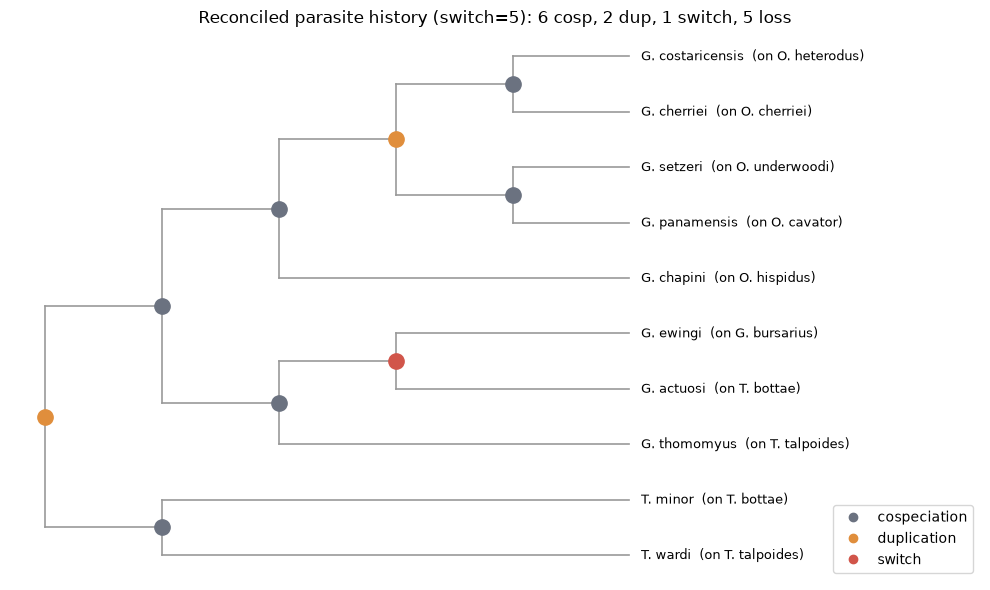

In [8]:
# Chunk 7: visualize the reconciliation — colour each ancestor by its event.
import matplotlib.pyplot as plt

EVENT_COLOR = {'cospeciation': '#6b7280', 'duplication': '#e08e3c', 'switch': '#d1554a'}

def reconcile_events(host_tree, parasite_tree, phi, C):
    INF = float('inf')
    host_nodes = list(host_tree.find_clades())
    host_post = list(host_tree.find_clades(order='postorder'))
    hbn = {l.name: l for l in host_tree.get_terminals()}
    desc = {h: set(h.find_clades()) for h in host_nodes}
    inc = {h: [g for g in host_nodes if g not in desc[h] and h not in desc[g]] for h in host_nodes}
    cost, bb = {}, {}
    A = lambda p, h: cost.get((p, h), INF)
    B = lambda p, h: bb.get((p, h), INF)
    for p in parasite_tree.find_clades(order='postorder'):
        if p.is_terminal():
            cost[(p, hbn[phi[p.name]])] = 0
        else:
            a, b = p.clades
            for h in host_nodes:
                o = []
                if not h.is_terminal():
                    h1, h2 = h.clades
                    o.append(C['cospeciation'] + min(B(a, h1) + B(b, h2), B(a, h2) + B(b, h1)))
                o.append(C['duplication'] + B(a, h) + B(b, h))
                ja = min([B(a, g) for g in inc[h]], default=INF)
                jb = min([B(b, g) for g in inc[h]], default=INF)
                o.append(C['switch'] + min(B(a, h) + jb, B(b, h) + ja))
                if min(o) < INF:
                    cost[(p, h)] = min(o)
        for h in host_post:
            if h.is_terminal():
                v = A(p, h)
            else:
                h1, h2 = h.clades
                v = min(A(p, h), C['loss'] + B(p, h1), C['loss'] + B(p, h2))
            if v < INF:
                bb[(p, h)] = v

    event_at, host_of, counts = {}, {}, {'cospeciation': 0, 'duplication': 0, 'switch': 0, 'loss': 0}
    def trace_exact(p, h):
        host_of[p] = h
        if p.is_terminal():
            return
        a, b = p.clades
        t = A(p, h)
        if not h.is_terminal():
            h1, h2 = h.clades
            for ca, cb in [(h1, h2), (h2, h1)]:
                if t == C['cospeciation'] + B(a, ca) + B(b, cb):
                    event_at[p] = 'cospeciation'; counts['cospeciation'] += 1
                    trace_below(a, ca); trace_below(b, cb); return
        if t == C['duplication'] + B(a, h) + B(b, h):
            event_at[p] = 'duplication'; counts['duplication'] += 1
            trace_below(a, h); trace_below(b, h); return
        ja = min([B(a, g) for g in inc[h]], default=INF)
        jb = min([B(b, g) for g in inc[h]], default=INF)
        if t == C['switch'] + B(a, h) + jb:
            event_at[p] = 'switch'; counts['switch'] += 1
            trace_below(a, h); trace_below(b, min(inc[h], key=lambda g: B(b, g))); return
        if t == C['switch'] + B(b, h) + ja:
            event_at[p] = 'switch'; counts['switch'] += 1
            trace_below(b, h); trace_below(a, min(inc[h], key=lambda g: B(a, g))); return
    def trace_below(p, h):
        if B(p, h) == A(p, h):
            trace_exact(p, h); return
        h1, h2 = h.clades
        for hc in (h1, h2):
            if B(p, h) == C['loss'] + B(p, hc):
                counts['loss'] += 1
                trace_below(p, hc); return
    trace_exact(parasite_tree.root, min(host_nodes, key=lambda h: A(parasite_tree.root, h)))
    return event_at, host_of, counts


def positions(tree):
    depths = tree.depths(unit_branch_lengths=True)
    xp = {c: (max(depths.values()) if c.is_terminal() else depths[c]) for c in depths}
    yp = {leaf: float(i) for i, leaf in enumerate(tree.get_terminals())}
    def sy(c):
        for ch in c.clades:
            if ch not in yp:
                sy(ch)
        if c.clades:
            yp[c] = (yp[c.clades[0]] + yp[c.clades[-1]]) / 2
    sy(tree.root)
    return xp, yp


event_at, host_of, counts = reconcile_events(host_tree, parasite_tree, mapping, C)
xp, yp = positions(parasite_tree)

fig, ax = plt.subplots(figsize=(10, 6))
for clade in parasite_tree.find_clades():
    for ch in clade.clades:
        ax.plot([xp[clade], xp[clade]], [yp[clade], yp[ch]], color='#999', lw=1.2)
        ax.plot([xp[clade], xp[ch]], [yp[ch], yp[ch]], color='#999', lw=1.2)
for node, ev in event_at.items():
    ax.plot(xp[node], yp[node], 'o', color=EVENT_COLOR[ev], markersize=11, zorder=3)
for leaf in parasite_tree.get_terminals():
    ax.text(xp[leaf] + 0.1, yp[leaf], f'{leaf.name}  (on {host_of[leaf].name})', va='center', fontsize=9)

handles = [plt.Line2D([], [], marker='o', ls='', color=c, label=e) for e, c in EVENT_COLOR.items()]
ax.legend(handles=handles, loc='lower right')
ax.set_title(f"Reconciled parasite history (switch={C['switch']}): "
             f"{counts['cospeciation']} cosp, {counts['duplication']} dup, "
             f"{counts['switch']} switch, {counts['loss']} loss")
ax.axis('off')
ax.set_xlim(-0.3, max(xp.values()) + 3)
plt.tight_layout()
plt.show()